In [40]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib, subprocess, sys

from rdkit import Chem
from rdkit.Chem import Descriptors

In [ ]:
# def ensure(pkg):
#     try:
#         importlib.import_module(pkg)
#     except Exception:
#         print(f"installing {pkg} ...")
#         subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
        
# for pkg in ("scipy", "numpy", "pandas", "statsmodels", "scikit_posthocs"):
#     ensure(pkg)
# print("done")

In [45]:
from scipy import stats
from itertools import combinations
from statsmodels.stats.multitest import multipletests
from math import comb

In [6]:
current_path = os.getcwd()
print("Current:", current_path)

os.chdir("/home/ssm-user/project")
print("Working on:", os.getcwd())

Current: /home/ssm-user/project
Working on: /home/ssm-user/project


In [8]:
batch_files = [f"smiles_batch_{i}.csv" for i in range(1, 6)]
dfs = []
for f in batch_files:
    df = pd.read_csv(f)
    col = [c for c in df.columns if "smi" in c.lower()][0]
    df = df.rename(columns={col: "SMILES"})
    df["batch"] = f
    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)
# print(all_df.head())
print(all_df["batch"].value_counts())


batch
smiles_batch_1.csv    20032
smiles_batch_2.csv    20032
smiles_batch_3.csv    20032
smiles_batch_4.csv    20032
smiles_batch_5.csv    20032
Name: count, dtype: int64


In [10]:
def canon_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol:
            return Chem.MolToSmiles(mol, isomericSmiles=True)
    except:
        return None
    return None

all_df["can_smi"] = all_df["SMILES"].apply(canon_smiles)


In [11]:
print("total:", len(all_df))
print("unique:", all_df["can_smi"].nunique())

total: 100160
unique: 100157


In [12]:
print(all_df.groupby("batch")["can_smi"].nunique())

batch
smiles_batch_1.csv    20032
smiles_batch_2.csv    20032
smiles_batch_3.csv    20032
smiles_batch_4.csv    20032
smiles_batch_5.csv    20032
Name: can_smi, dtype: int64


In [13]:
dup_counts = all_df.duplicated("can_smi").sum()
print("duplicates:", dup_counts)

duplicates: 3


In [14]:
dup_df = all_df.groupby("can_smi")["batch"].unique().reset_index()
cross_dup = dup_df[dup_df["batch"].apply(lambda x: len(x) > 1)]
print(cross_dup)

                                                 can_smi  \
18015     CCCc1cc(C(=O)N[C@H]2CCOC[C@H]2Nc2ccnc(C)n2)no1   
74532     Cn1nc(C[C@H]2CCCC[C@H]2NCc2nnnn2C2CC2)n(C)c1=O   
97505  O=S(=O)(c1cccc(-c2ccccc2)c1)N1CC2(CCNCC2)[C@H]...   

                                          batch  
18015  [smiles_batch_2.csv, smiles_batch_4.csv]  
74532  [smiles_batch_2.csv, smiles_batch_3.csv]  
97505  [smiles_batch_2.csv, smiles_batch_4.csv]  


In [ ]:
### 현재 batch_2에서 batch_3과 batch_4에 총 3개의 중복이 발견 -> 제외하는 것이 좋음
### 제외한 후의 결과는 아래와 같음
### can_smi = cannonical smiles의 줄임 인덱싱

### total can_smi: 100,157

### batch:       can_smi:
### batch_1      20032
### batch_2      20029
### batch_3      20032
### batch_4      20032
### batch_5      20032

In [15]:
dups_in_batch2 = cross_dup[cross_dup["batch"].apply(lambda x: "smiles_batch_2.csv" in x)]["can_smi"]
all_df = all_df.drop(
    all_df[(all_df["batch"]=="smiles_batch_2.csv") & (all_df["can_smi"].isin(dups_in_batch2))].index
)


In [17]:
print(all_df.groupby("batch")["can_smi"].nunique())
dup_counts = all_df.duplicated("can_smi").sum()
print("duplicates:", dup_counts)

batch
smiles_batch_1.csv    20032
smiles_batch_2.csv    20029
smiles_batch_3.csv    20032
smiles_batch_4.csv    20032
smiles_batch_5.csv    20032
Name: can_smi, dtype: int64
duplicates: 0


In [18]:
def compute_props(smi):
    mol = Chem.MolFromSmiles(smi)
    if not mol:
        return None, None, None, None
    return (Descriptors.ExactMolWt(mol),
            Descriptors.MolLogP(mol),
            Descriptors.TPSA(mol),
            Descriptors.NumRotatableBonds(mol))

all_df[["MW","logP","TPSA","RotB"]] = all_df["can_smi"].apply(
    lambda x: pd.Series(compute_props(x))
)
print(all_df.groupby("batch")[["MW","logP","TPSA","RotB"]].describe().round(2))

                         MW                                                 \
                      count    mean    std     min     25%     50%     75%   
batch                                                                        
smiles_batch_1.csv  20032.0  339.01  41.46  236.13  311.25  338.11  365.14   
smiles_batch_2.csv  20029.0  333.89  38.99  236.09  307.18  334.10  357.17   
smiles_batch_3.csv  20032.0  338.25  41.68  235.11  310.18  338.07  365.08   
smiles_batch_4.csv  20032.0  336.40  40.44  235.09  310.10  336.07  361.00   
smiles_batch_5.csv  20032.0  337.71  40.28  238.11  311.15  337.15  362.08   

                               logP        ...   TPSA             RotB        \
                       max    count  mean  ...    75%     max    count  mean   
batch                                      ...                                 
smiles_batch_1.csv  498.18  20032.0  2.62  ...  83.20  149.67  20032.0  4.30   
smiles_batch_2.csv  520.11  20029.0  2.37  ...  85.25  

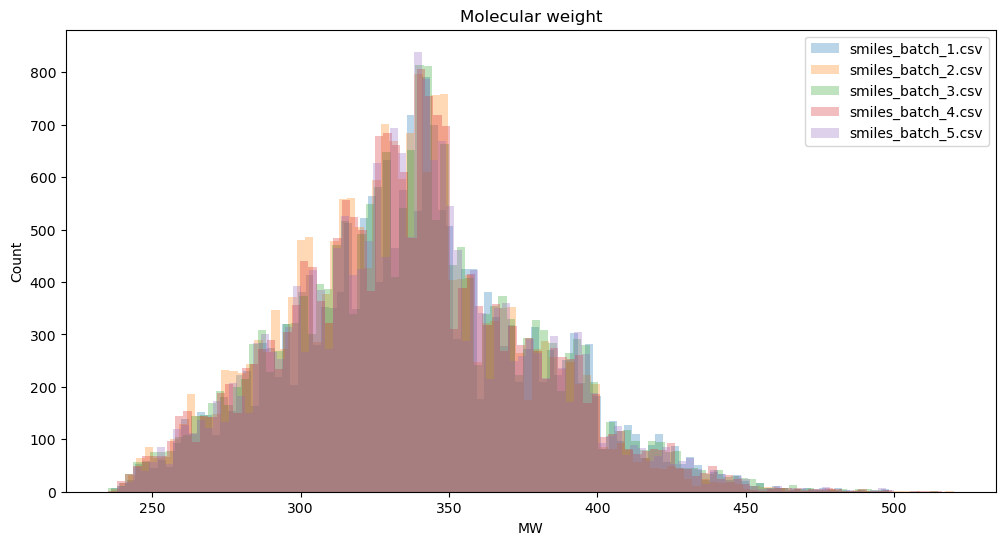

In [34]:
plt.figure(figsize=(12,6))
for b in all_df['batch'].unique():
    subset = all_df[all_df['batch']==b]
    plt.hist(subset['MW'], bins=100, alpha=0.3, label=b)
plt.xlabel('MW')
plt.ylabel('Count')
plt.title('Molecular weight')
plt.legend()
plt.show()

In [ ]:
# plt.figure(figsize=(12,6))
# data_to_plot = [all_df[all_df['batch']==b]['logP'] for b in all_df['batch'].unique()]
# plt.boxplot(data_to_plot, labels=all_df['batch'].unique())
# plt.ylabel('logP')
# plt.show()

In [ ]:
# plt.figure(figsize=(12,6))
# data_to_plot = [all_df[all_df['batch']==b]['TPSA'] for b in all_df['batch'].unique()]
# plt.violinplot(data_to_plot)
# plt.xticks(range(1,len(all_df['batch'].unique())+1), all_df['batch'].unique())
# plt.ylabel('TPSA')
# plt.show()

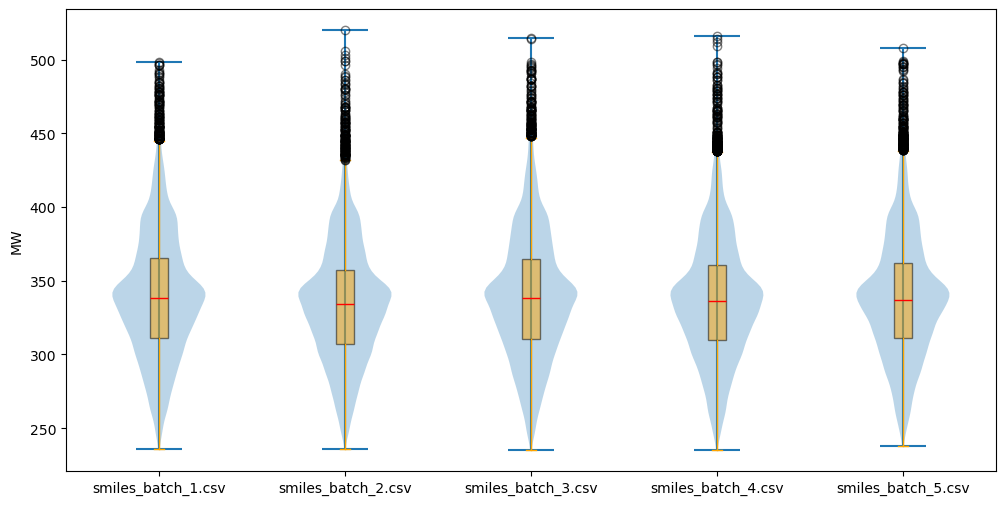

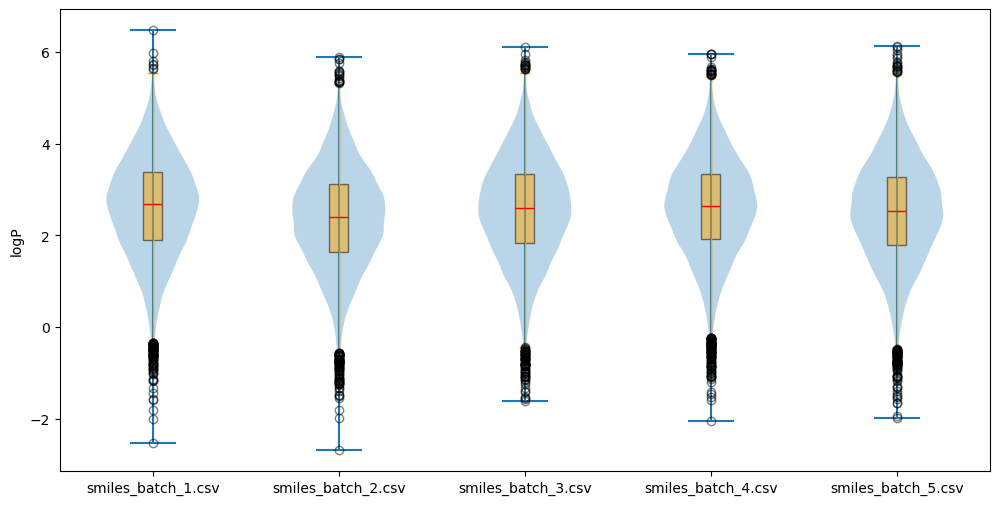

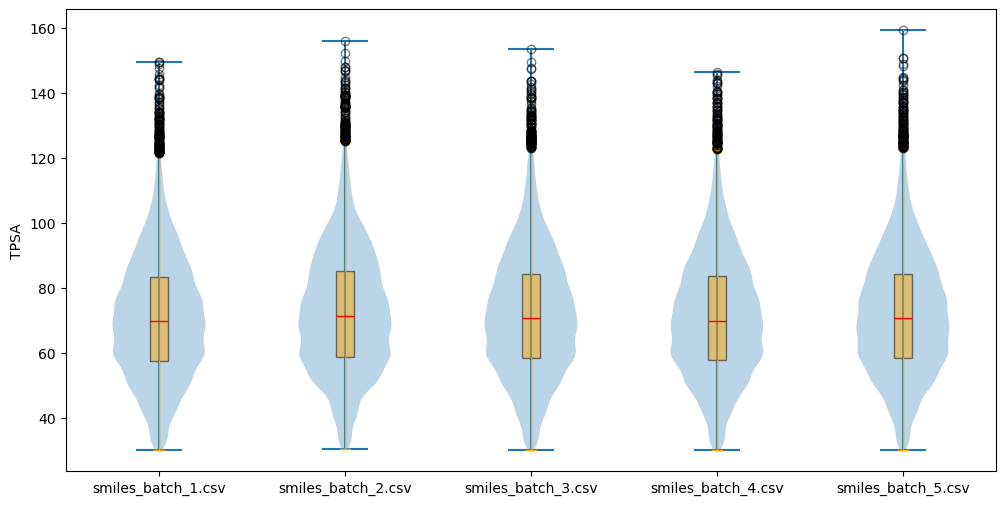

In [39]:
features = ["MW", "logP", "TPSA"]

for feat in features:
    plt.figure(figsize=(12,6))
    
    data_to_plot = [all_df[all_df['batch']==b][feat] for b in all_df['batch'].unique()]
    batches = list(all_df['batch'].unique())
    
    vp = plt.violinplot(data_to_plot, positions=range(len(batches)), showmeans=False, showmedians=False)
    for pc in vp['bodies']:
        pc.set_alpha(0.3)
    
    bp = plt.boxplot(data_to_plot, positions=range(len(batches)), widths=0.1, patch_artist=True,
                     boxprops=dict(facecolor='orange', alpha=0.5),
                     medianprops=dict(color='red'),
                     whiskerprops=dict(color='orange'),
                     capprops=dict(color='orange'),
                     flierprops=dict(marker='o', color='orange', alpha=0.5),
                     tick_labels=batches)
    
    plt.xticks(range(len(batches)), batches)
    plt.ylabel(feat)
    plt.show()

In [47]:
features = ["MW","logP","TPSA"]
batches = list(all_df['batch'].unique())
groups = {b: {feat: all_df[all_df['batch']==b][feat].dropna().values for feat in features} for b in batches}

In [48]:
global_results = {}
for feat in features:
    group_list = [groups[b][feat] for b in batches]
    # Kruskal (비모수 전체 비교)
    try:
        H, p_global = stats.kruskal(*group_list)
    except Exception as e:
        H, p_global = np.nan, np.nan
    global_results[feat] = {"H": H, "p": p_global}
    print(f"\nFeature {feat}: Kruskal-Wallis H={H:.3e}, p={p_global:.3e}")


Feature MW: Kruskal-Wallis H=1.672e+02, p=4.135e-35

Feature logP: Kruskal-Wallis H=7.232e+02, p=3.359e-155

Feature TPSA: Kruskal-Wallis H=1.315e+02, p=1.826e-27


In [49]:
pairwise_results = {}
for feat in features:
    pairs = list(combinations(batches, 2))
    raw_p = []
    pair_names = []
    for a,b in pairs:
        xa = groups[a][feat]
        xb = groups[b][feat]
        # require at least 3 points in each group to test; otherwise p=nan
        if len(xa) < 3 or len(xb) < 3:
            p = np.nan
        else:
            try:
                stat, p = stats.mannwhitneyu(xa, xb, alternative='two-sided')
            except Exception:
                p = np.nan
        raw_p.append(p)
        pair_names.append((a,b))
        
    # Bonferroni correction
    m = len(raw_p)
    adj = [min(p*m, 1.0) if not np.isnan(p) else np.nan for p in raw_p]

    pmat = pd.DataFrame(np.ones((len(batches),len(batches))), index=batches, columns=batches)
    for (a,b), p_adj in zip(pair_names, adj):
        pmat.loc[a,b] = p_adj
        pmat.loc[b,a] = p_adj
    pairwise_results[feat] = {"pairs": pair_names, "raw_p": raw_p, "adj_p": adj, "pmat": pmat}

    sigs = [(pair_names[i], adj[i]) for i in range(len(adj)) if (not np.isnan(adj[i]) and adj[i] < 0.05)]
    print(f"\n{feat} - significant pairs after Bonferroni ({len(sigs)}):")
    if sigs:
        for pr, pval in sigs:
            print(f"{pr[0]} vs {pr[1]} : p_adj = {pval:.3e}")
    else:
        print("None")


MW - significant pairs after Bonferroni (7):
smiles_batch_1.csv vs smiles_batch_2.csv : p_adj = 4.933e-30
smiles_batch_1.csv vs smiles_batch_4.csv : p_adj = 2.397e-08
smiles_batch_2.csv vs smiles_batch_3.csv : p_adj = 8.582e-22
smiles_batch_2.csv vs smiles_batch_4.csv : p_adj = 1.910e-07
smiles_batch_2.csv vs smiles_batch_5.csv : p_adj = 4.355e-18
smiles_batch_3.csv vs smiles_batch_4.csv : p_adj = 2.149e-04
smiles_batch_4.csv vs smiles_batch_5.csv : p_adj = 1.110e-02

logP - significant pairs after Bonferroni (9):
smiles_batch_1.csv vs smiles_batch_2.csv : p_adj = 1.657e-121
smiles_batch_1.csv vs smiles_batch_3.csv : p_adj = 2.987e-06
smiles_batch_1.csv vs smiles_batch_5.csv : p_adj = 2.433e-22
smiles_batch_2.csv vs smiles_batch_3.csv : p_adj = 1.083e-73
smiles_batch_2.csv vs smiles_batch_4.csv : p_adj = 8.364e-110
smiles_batch_2.csv vs smiles_batch_5.csv : p_adj = 1.066e-40
smiles_batch_3.csv vs smiles_batch_4.csv : p_adj = 3.338e-03
smiles_batch_3.csv vs smiles_batch_5.csv : p_adj =

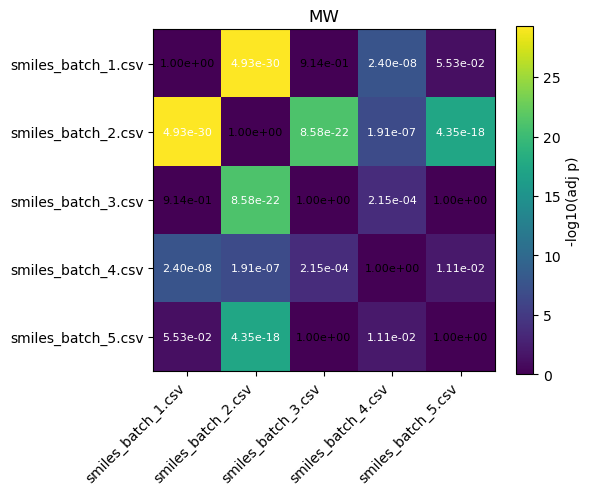

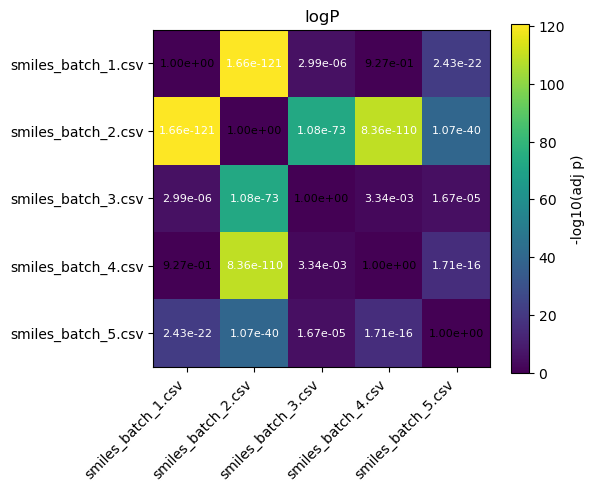

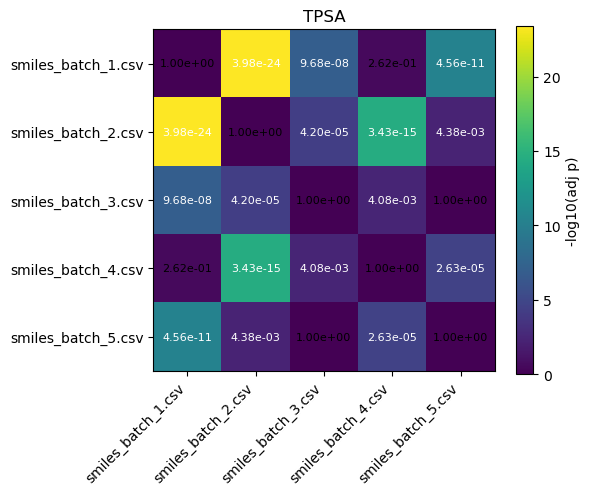

In [51]:
for feat in features:
    pmat = pairwise_results[feat]['pmat']
    fig, ax = plt.subplots(figsize=(6,5))
    # display p as -log10 for visibility, but annotate with raw p
    pvals = pmat.values.astype(float)
    viz = -np.log10(np.clip(pvals, 1e-300, 1.0))
    im = ax.imshow(viz, cmap='viridis')
    ax.set_xticks(np.arange(len(batches))); ax.set_yticks(np.arange(len(batches)))
    ax.set_xticklabels(batches, rotation=45, ha='right'); ax.set_yticklabels(batches)
    for i in range(len(batches)):
        for j in range(len(batches)):
            text = f"{pmat.values[i,j]:.2e}"
            ax.text(j,i, text, ha='center', va='center', color='white' if viz[i,j]>1 else 'black', fontsize=8)
    fig.colorbar(im, ax=ax, label='-log10(adj p)')
    plt.title(feat)
    plt.tight_layout()
    plt.show()